In [1]:
import pandas as pd

df = pd.read_parquet("../outputs/user_anomaly_scores.parquet")
df.head()

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.233902,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.232997,1,2
2,y8aWXOimQ9ZgUgZ6q--nCQ,3.868996,0.344978,0.056769,229,0.033956,6744.0,1716.0,0.231222,1,3
3,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.230635,1,4
4,Ase_kJIYuT6yOsqqVPuWUA,3.526515,0.219697,0.053030,264,0.041089,6425.0,1793.0,0.229916,1,5


In [3]:
# Showing which is an anomaly
df[df["is_anomaly"] == 1].head(20)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.233902,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.232997,1,2
2,y8aWXOimQ9ZgUgZ6q--nCQ,3.868996,0.344978,0.056769,229,0.033956,6744.0,1716.0,0.231222,1,3
3,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.230635,1,4
4,Ase_kJIYuT6yOsqqVPuWUA,3.526515,0.219697,0.053030,264,0.041089,6425.0,1793.0,0.229916,1,5
5,kS1MQHYwIfD0462PE61IBw,3.668293,0.209756,0.009756,205,0.030067,6818.0,2003.0,0.229781,1,6
6,qWYEuBZP7av55tewg3PXKg,3.768156,0.265363,0.039106,358,0.061682,5804.0,3490.0,0.229738,1,7
7,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.229560,1,8
8,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.228659,1,9
9,KDewJBJknfWvQyHHFNbfdg,4.149038,0.379808,0.009615,208,0.030842,6744.0,3964.0,0.228503,1,10


In [4]:
df[df["is_anomaly"] == 1][[
    "avg_stars_given",
    "pct_5_star_reviews",
    "review_count",
    "reviews_per_day",
    "num_friends"
]].describe()

,avg_stars_given,pct_5_star_reviews,review_count,reviews_per_day,num_friends
count,72300.000000,72300.000000,72300.000000,72300.000000,72300.000000
mean,3.268405,0.339423,23.828631,0.005254,304.102697
std,1.219149,0.290802,39.312930,0.007942,519.825231
min,1.000000,0.000000,1.000000,0.000127,0.000000
25%,2.400000,0.076923,4.000000,0.001012,9.000000
50%,3.638426,0.300000,14.000000,0.003346,120.000000
75%,4.171429,0.518519,28.000000,0.006287,426.000000
max,5.000000,1.000000,1704.000000,0.269386,14995.000000


In [24]:
import pandas as pd
from pathlib import Path

# Load your Phase 2 results
PROJECT_ROOT = Path.cwd().parent
ANOMALY_PATH = PROJECT_ROOT / "outputs" / "user_anomaly_scores.parquet"

df = pd.read_parquet(ANOMALY_PATH)

# Find users with 0 friends who are in anomaly list
# bots
bots = top_anomalies[
    (top_anomalies['num_friends'] == 0) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

# Find "Review Bombers" 
# (Using 0.1 instead of 1.0 based on your max of 0.26)
bombers = top_anomalies[
    (top_anomalies['reviews_per_day'] > 0.1) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

print("0 Friends + Anomalous (bots)")
display(bots)

print("\n High Velocity + Anomalous (Review Bombers)")
display(bombers)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
0 Friends + Anomalous (bots)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
587,QG-5Xa3R9_TmDDL4g9BiRA,1.892857,0.190476,0.690476,84,0.033830,2483.0,0.0,0.190483,1,588
1013,Z6gS-BqSWT35vY1XtGLLeQ,1.779412,0.088235,0.573529,68,0.027857,2441.0,0.0,0.180848,1,1014
1111,sGCCjnXG_3SoUmqwyswEfA,2.118519,0.125926,0.540741,135,0.027185,4966.0,0.0,0.179004,1,1112
1235,hPtHL1JLtYIIrCDhrjUBaQ,2.932886,0.231544,0.265101,298,0.056026,5319.0,0.0,0.176989,1,1236
1321,S84rIUvqA2S0gtpmoK3k_w,3.391705,0.156682,0.046083,217,0.036017,6025.0,0.0,0.175710,1,1322
1335,R-c5M0iJkMxxTxIqTQQZ8w,2.836272,0.015113,0.040302,397,0.064229,6181.0,0.0,0.175442,1,1336
1448,bIw6zquJOoUyUaidD85q4Q,4.791667,0.875000,0.013889,72,0.043663,1649.0,0.0,0.173788,1,1449
1482,LM7ebdJWVsmx6hGAo6qa5A,2.827160,0.111111,0.197531,162,0.029818,5433.0,0.0,0.173347,1,1483
1614,_nQkbNbAhSHZ7ccnsPM4cg,1.578125,0.093750,0.781250,64,0.019318,3313.0,0.0,0.171680,1,1615
1798,K8_kxQ6IQ_4O8RXioJd8uQ,2.797386,0.104575,0.183007,153,0.034537,4430.0,0.0,0.169573,1,1799



 High Velocity + Anomalous (Review Bombers)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
3,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.230635,1,4
7,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.229560,1,8
15,ET8n-r7glWYqZhuR6GcdNw,3.971154,0.298951,0.006119,1144,0.173281,6602.0,5958.0,0.227734,1,16
25,ouODopBKF3AqfCkuQEnrDg,3.571130,0.116109,0.026151,956,0.163140,5860.0,1141.0,0.226712,1,26
46,pou3BbKsIozfH50rxmnMew,4.197105,0.419822,0.005568,898,0.172097,5218.0,4024.0,0.224471,1,47
47,qjfMBIZpQT9DDtw_BWCopQ,3.728771,0.318124,0.038023,789,0.137985,5718.0,965.0,0.224414,1,48
50,-G7Zkl1wIWBBmD0KRy_sCw,3.589823,0.147263,0.017733,1297,0.265888,4878.0,1787.0,0.224082,1,51
51,h7p-GuaHFGsiKCF4g6Bjqg,3.535792,0.104121,0.006508,461,0.103155,4469.0,2729.0,0.224050,1,52
53,A9cXP_K95FRor1qxuUEu2g,3.647558,0.148620,0.012739,471,0.109586,4298.0,1173.0,0.223771,1,54
54,CfX4sTIFFNaRchNswqhVfg,3.526634,0.294189,0.101695,826,0.147237,5610.0,891.0,0.223759,1,55


In [10]:
# Calculate correlation between all numeric columns
correlation_matrix = df[["anomaly_score", "num_friends", "reviews_per_day", "review_count"]].corr()

# Specifically look at the relationship with anomaly_score
print("Correlation with Anomaly Score:")
print(correlation_matrix["anomaly_score"].sort_values(ascending=False))

Correlation with Anomaly Score:
anomaly_score      1.000000
reviews_per_day    0.504473
review_count       0.474385
num_friends        0.387104
Name: anomaly_score, dtype: float64


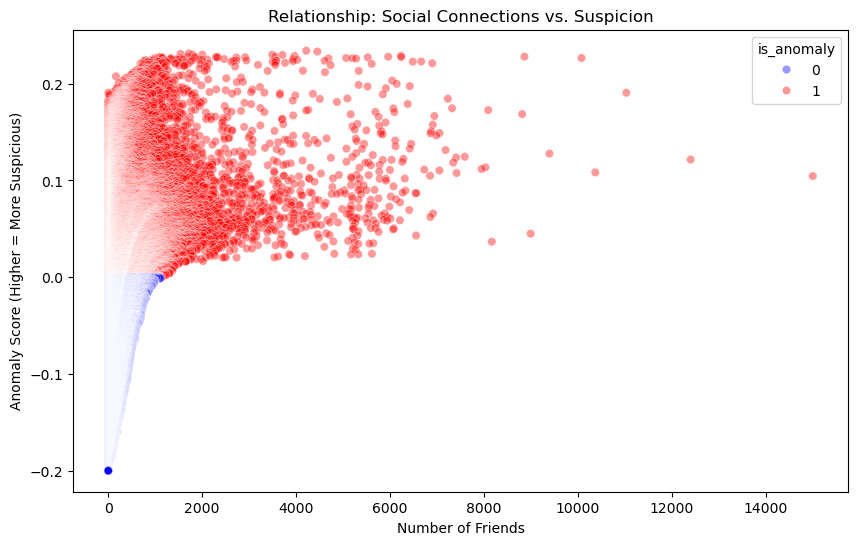

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# We use a scatter plot to see where the anomalies (red) sit compared to normal users (blue)
sns.scatterplot(
    data=df, 
    x="num_friends", 
    y="anomaly_score", 
    hue="is_anomaly", 
    palette={0: "blue", 1: "red"},
    alpha=0.4
)

plt.title("Relationship: Social Connections vs. Suspicion")
plt.xlabel("Number of Friends")
plt.ylabel("Anomaly Score (Higher = More Suspicious)")
plt.show()

Strong relationship between social connectivity (friends) and suspicion. 
The model heavily flags users with zero friends as high-risk anomalies (the red cluster at x=0), while also isolating 'Extreme Power Users' with outlier friend counts exceeding 10,000

In [16]:
# Filter only for the anomalies identified by your model
anomalies_only = df[df["is_anomaly"] == 1]

# 1. High-rating anomalous users
high_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] >= 4.5]
    .sort_values("anomaly_score", ascending=False)
)

# 2. Low-rating anomalous users
low_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] <= 1.5]
    .sort_values("anomaly_score", ascending=False)
)

print(f"Found {len(high_rating_anomalies)} high-rating anomalous users")
print(f"Found {len(low_rating_anomalies)} low-rating anomalous users")

# Display a preview for case_studies.md
print("\n--- HIGH-RATING ANOMALOUS USERS PREVIEW ---")
display(
    high_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

print("\n--- LOW-RATING ANOMALOUS USERS PREVIEW ---")
display(
    low_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

Found 9884 high-rating anomalous users
Found 11194 low-rating anomalous users

--- HIGH-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
58,wYlael7ejt4I3vjaXmpGnA,4.545833,0.066983,2671.0
85,tuoDDqTDCB-lDgelvMrp5Q,4.571429,0.089208,1139.0
151,4DyMRBKrokax6d8LCI3GAw,4.613208,0.015351,4143.0
176,AVyU4MC9ucdgCFRaLNpePQ,4.661721,0.072489,741.0
179,Y-fPeP9dmciMYg83esNSWw,4.500000,0.027512,1147.0



--- LOW-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
674,oDlFUW7dJmQBP-czr_tVqg,1.292683,0.027554,19.0
883,wtkM3aDAJZyPo5qdG8ATrw,1.444444,0.024523,1.0
1745,D1LD4rsQi1W1iR7zb_Neaw,1.363636,0.008569,327.0
2619,YpZByJIgbMsTvPdOjURFsg,1.490909,0.010097,4.0
4116,DdrP5ng377vmc8vEePLcDw,1.270833,0.010721,0.0


In [13]:
# Note: This assumes you have access to the raw reviews to see WHERE they posted.
# If you don't have the reviews loaded yet, you'll need to load them:
# reviews_df = pd.read_parquet("../data/raw/reviews.parquet")

# 1. Get the list of IDs for your top 100 anomalies
top_anomaly_ids = top_anomalies['user_id'].head(100).tolist()

# 2. Filter reviews to see which businesses were reviewed by these specific users
# target_businesses = reviews_df[reviews_df['user_id'].isin(top_anomaly_ids)]

# 3. Find businesses with the most "Anomalous" reviews
# suspicious_biz = target_businesses.groupby('business_id').size().sort_values(ascending=False)
# print("Businesses with the most hits from anomalous users:")
# print(suspicious_biz.head(10))

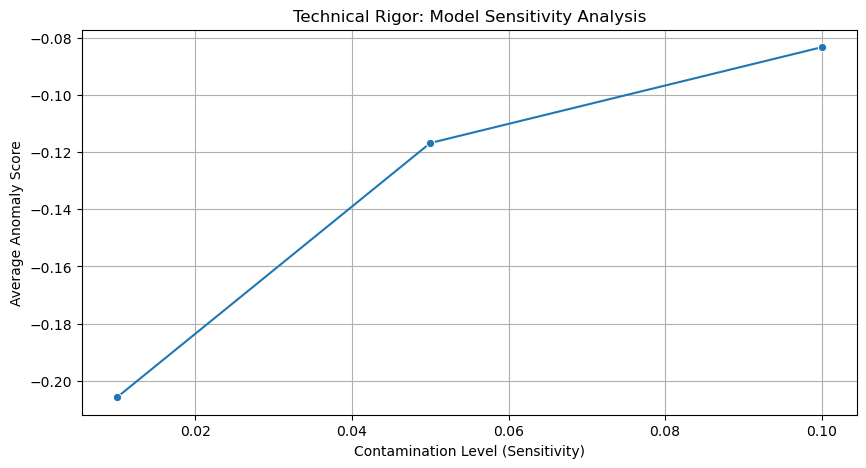

,config_name,contamination,n_anomalies,anomaly_rate
0,v1_c001,0.01,14460,0.01
1,v1_c005,0.05,72300,0.05
2,v1_c010,0.10,144599,0.10


In [14]:
# Load the summary of your experiments
runs_df = pd.read_parquet("../outputs/user_anomaly_model_runs.parquet")

# Visualize the trade-off between Contamination and the Anomaly Score Mean
plt.figure(figsize=(10, 5))
sns.linemarker = sns.lineplot(data=runs_df, x="contamination", y="anomaly_score_mean", marker="o")
plt.title("Technical Rigor: Model Sensitivity Analysis")
plt.xlabel("Contamination Level (Sensitivity)")
plt.ylabel("Average Anomaly Score")
plt.grid(True)
plt.show()

display(runs_df[["config_name", "contamination", "n_anomalies", "anomaly_rate"]])

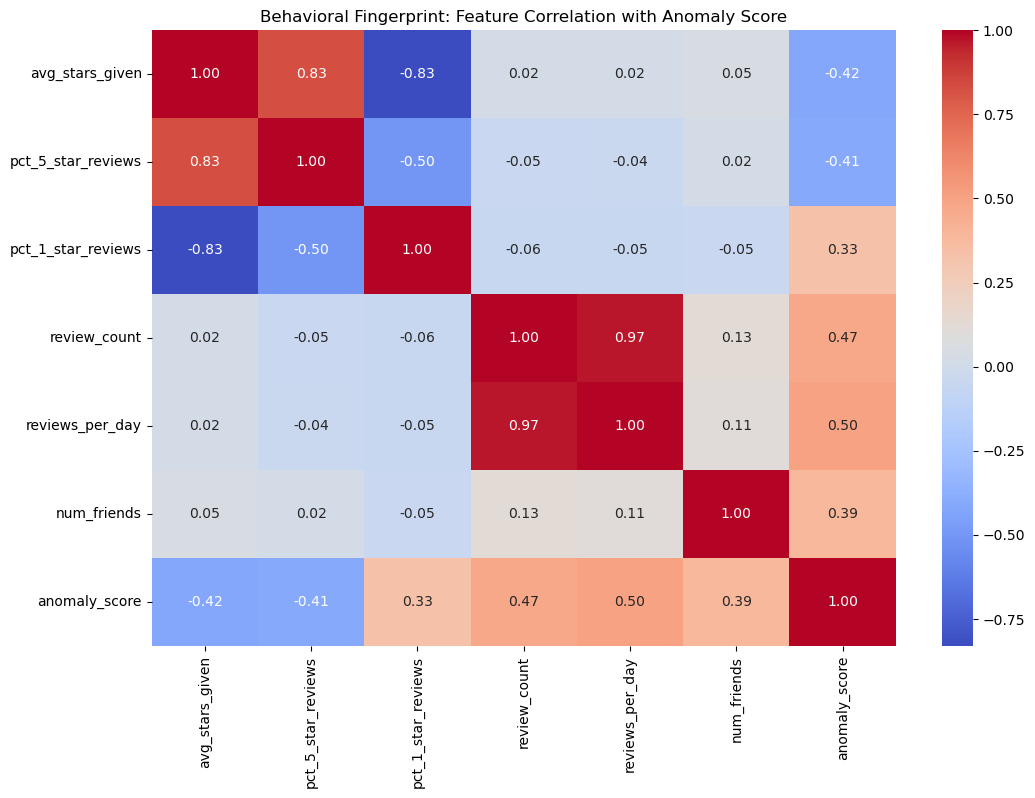

In [15]:
# Features used in your model
features = ["avg_stars_given", "pct_5_star_reviews", "pct_1_star_reviews", 
            "review_count", "reviews_per_day", "num_friends", "anomaly_score"]

plt.figure(figsize=(12, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Behavioral Fingerprint: Feature Correlation with Anomaly Score")
plt.show()

In [20]:
#  top 5 users ranked as most anomalous, along with key behavioral features
df[df["anomaly_rank"] <= 5][["user_id", "review_count", "reviews_per_day", "num_friends", "anomaly_score"]]

,user_id,review_count,reviews_per_day,num_friends,anomaly_score
0,nnImk681KaRqUVHlSfZjGQ,499,0.069104,4214.0,0.233902
1,6s-g2vFu12OemhiK3FJuOQ,689,0.098288,4449.0,0.232997
2,y8aWXOimQ9ZgUgZ6q--nCQ,229,0.033956,1716.0,0.231222
3,bJ5FtCtZX3ZZacz2_2PJjA,765,0.111500,1538.0,0.230635
4,Ase_kJIYuT6yOsqqVPuWUA,264,0.041089,1793.0,0.229916


In [22]:
# Looking for extreme suspicious behavior
# Finds users who: are flagged as anomalies AND give almost all 5-star OR all 1-star reviews
suspicious_extreme = df[
    (df["is_anomaly"] == 1) &
    (
        (df["pct_5_star_reviews"] > 0.95) |
        (df["pct_1_star_reviews"] > 0.95)
    )
]

suspicious_extreme = suspicious_extreme.sort_values("anomaly_score", ascending=False)
suspicious_extreme.head(10)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
1287,rHGnUvQBIPPw-BYxQL3zGg,5.000000,1.000000,0.000000,73,0.028361,2574.0,298.0,0.176115,1,1288
1376,XmBm3C-Y7TKHuMoEMO5AtQ,4.978723,0.978723,0.000000,94,0.013657,6883.0,440.0,0.174786,1,1377
1892,7NHf3QgyGlZ_9pwdWLFdhA,5.000000,1.000000,0.000000,162,0.041138,3938.0,133.0,0.168411,1,1893
2428,rfFCDTjJMN7ChYcCKkcHag,5.000000,1.000000,0.000000,70,0.016424,4262.0,446.0,0.162577,1,2429
2907,r9gEc0zaB1KWv551uxGG3w,4.964286,0.964286,0.000000,84,0.026906,3122.0,58.0,0.157400,1,2908
3096,iM9CaFMvyDcW7gKzO_vMaA,5.000000,1.000000,0.000000,21,0.008219,2555.0,716.0,0.155360,1,3097
3192,SuB52LlawFfoJQvzMGUN_Q,5.000000,1.000000,0.000000,27,0.006774,3986.0,1460.0,0.154502,1,3193
3236,_m0Sxb2_kUFtic4wGwIGzw,4.958333,0.958333,0.000000,24,0.010336,2322.0,558.0,0.154126,1,3237
3720,wF_CbmxgMKnC_ZnPcPCFqw,4.846154,0.961538,0.038462,26,0.004755,5468.0,1330.0,0.149304,1,3721
3810,A4WMwbeMsE8NZ8DJfOMONg,4.958904,0.958904,0.000000,73,0.027007,2703.0,1.0,0.148368,1,3811


In [23]:
suspicious_extreme[
    ["user_id", "avg_stars_given", "reviews_per_day", "review_count", "num_friends"]
].head(10)

,user_id,avg_stars_given,reviews_per_day,review_count,num_friends
1287,rHGnUvQBIPPw-BYxQL3zGg,5.000000,0.028361,73,298.0
1376,XmBm3C-Y7TKHuMoEMO5AtQ,4.978723,0.013657,94,440.0
1892,7NHf3QgyGlZ_9pwdWLFdhA,5.000000,0.041138,162,133.0
2428,rfFCDTjJMN7ChYcCKkcHag,5.000000,0.016424,70,446.0
2907,r9gEc0zaB1KWv551uxGG3w,4.964286,0.026906,84,58.0
3096,iM9CaFMvyDcW7gKzO_vMaA,5.000000,0.008219,21,716.0
3192,SuB52LlawFfoJQvzMGUN_Q,5.000000,0.006774,27,1460.0
3236,_m0Sxb2_kUFtic4wGwIGzw,4.958333,0.010336,24,558.0
3720,wF_CbmxgMKnC_ZnPcPCFqw,4.846154,0.004755,26,1330.0
3810,A4WMwbeMsE8NZ8DJfOMONg,4.958904,0.027007,73,1.0
